In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import numpy as np
from pyresample import geometry, kd_tree

from swath_merge import concatenate_tiles_along_track, merge_tiles_to_regular_grid

In [3]:
def plot_localisation_grid(data_path):
    # 1. Load the NetCDF file
    ds = xr.open_dataset(data_path)

    # 2. Identify the lat and lon variables
    # Often named 'lat'/'lon' or 'latitude'/'longitude'
    lons = ds.lon.values
    lats = ds.lat.values

    # 3. Setup the projection
    # PlateCarree is standard, but you could use ccrs.Orthographic() for a globe view
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add map features for context
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # 4. Plot the Localisation Grid
    # We plot a subset (every 10th or 50th point) so the lines are visible
    step = 50

    # 5. Add Latitude/Longitude Labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False   # Turn off labels on the top
    gl.right_labels = False # Turn off labels on the right
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

    # Plotting horizontal grid lines (rows)
    for i in range(0, lats.shape[0], step):
        ax.plot(lons[i, :], lats[i, :], color='red', transform=ccrs.Geodetic(), alpha=0.5, linewidth=0.5)

    # Plotting vertical grid lines (columns)
    for j in range(0, lons.shape[1], step):
        ax.plot(lons[:, j], lats[:, j], color='blue', transform=ccrs.Geodetic(), alpha=0.5, linewidth=0.5)

    ax.set_title("Satellite Localisation Grid (Curvilinear)")
    plt.show()

def plot_multiple_localisation_grid(file_list):
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    # Loop through multiple files and plot their localisation grids on the same map
    step = 100  # Adjust based on data density
    if len(file_list) > 7:
        colors = plt.cm.get_cmap('tab10', len(file_list)).colors  # Get a colormap with enough colors
    else:
        colors = ["red", "blue", "green", "orange", "purple", "cyan", "magenta"]  # Cycle through colors

    for i, file in enumerate(file_list):
        with xr.open_dataset(file) as ds:
            # Extract lats/lons (adjust names to match your file)
            lons = ds.lon.values
            lats = ds.lat.values

            # Plot horizontal grid lines
            for r in range(0, lats.shape[0], step):
                ax.plot(lons[r, :], lats[r, :], color=colors[i],
                        transform=ccrs.Geodetic(), alpha=0.3, linewidth=0.3)

            # Plot vertical grid lines
            for c in range(0, lons.shape[1], step):
                ax.plot(lons[:, c], lats[:, c], color=colors[i],
                        transform=ccrs.Geodetic(), alpha=0.3, linewidth=0.3)

    ax.set_title(f"Merged Localisation Grids: {len(file_list)} Traces")
    plt.show()

In [5]:
# plot_localisation_grid("/home/qbialota/Documents/Data/Satellites/hscat/hscat_20240420_034138_hy_2b__27562_o_250_2204_ovw_l2.nc")
ds = xr.open_dataset("/home/qbialota/Documents/Data/Satellites/hscat/hscat_20240420_034138_hy_2b__27562_o_250_2204_ovw_l2.nc")
ds

TypeError: _UFuncOutputCastingError.__init__() missing 4 required positional arguments: 'casting', 'from_', 'to', and 'i'

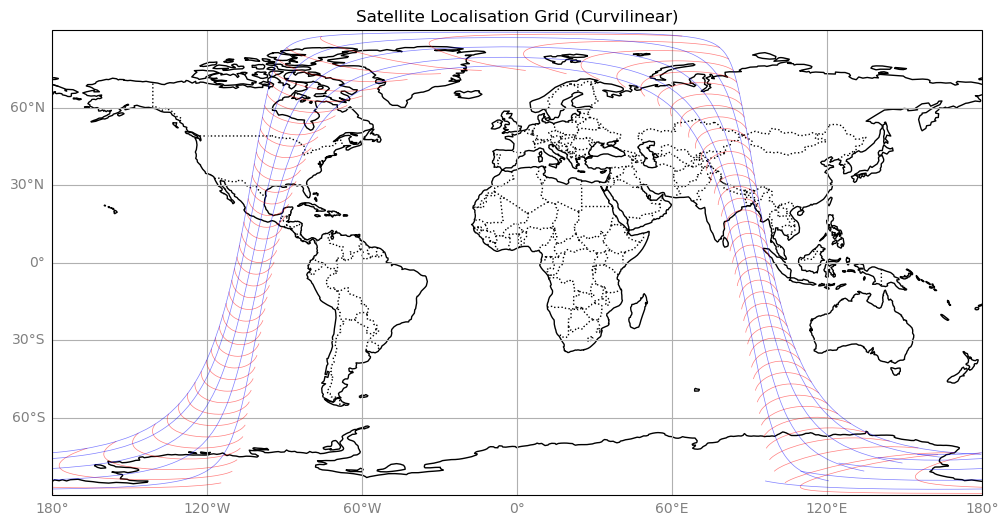

In [3]:
### AMSR2
DATA_FOLDER_PATH = "/home/qbialota/Documents/Data/Satellites/amsr2/"
DATA_NAME = "20240420070546-REMSS-L2P_GHRSST-SSTsubskin-AMSR2-L2B_v8.2_r63430-v02.0-fv01.0.nc"

plot_localisation_grid(DATA_FOLDER_PATH + DATA_NAME)

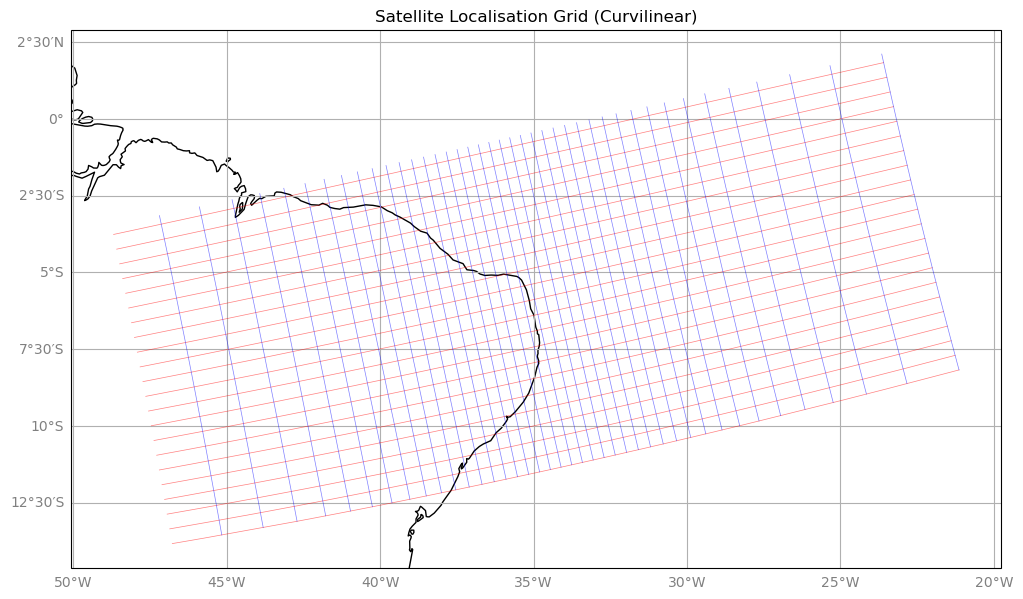

In [4]:
### AMSR2
DATA_FOLDER_PATH = "/home/qbialota/Téléchargements/"
DATA_NAME = "20250627232803-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST_METOP_B-sstmgr_metop01_20250627_232803-v02.0-fv01.0.nc"

plot_localisation_grid(DATA_FOLDER_PATH + DATA_NAME)

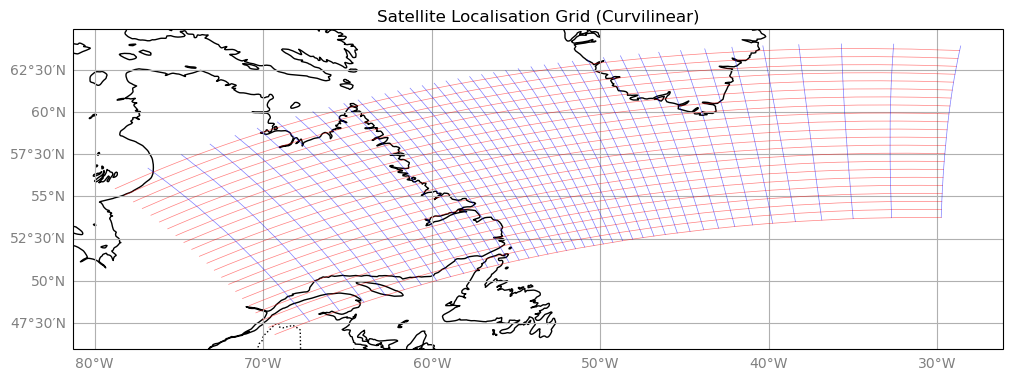

In [5]:
### AMSR2
DATA_FOLDER_PATH = "/home/qbialota/Téléchargements/"
DATA_NAME = "20250627234603-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST_METOP_B-sstmgr_metop01_20250627_234603-v02.0-fv01.0.nc"

plot_localisation_grid(DATA_FOLDER_PATH + DATA_NAME)

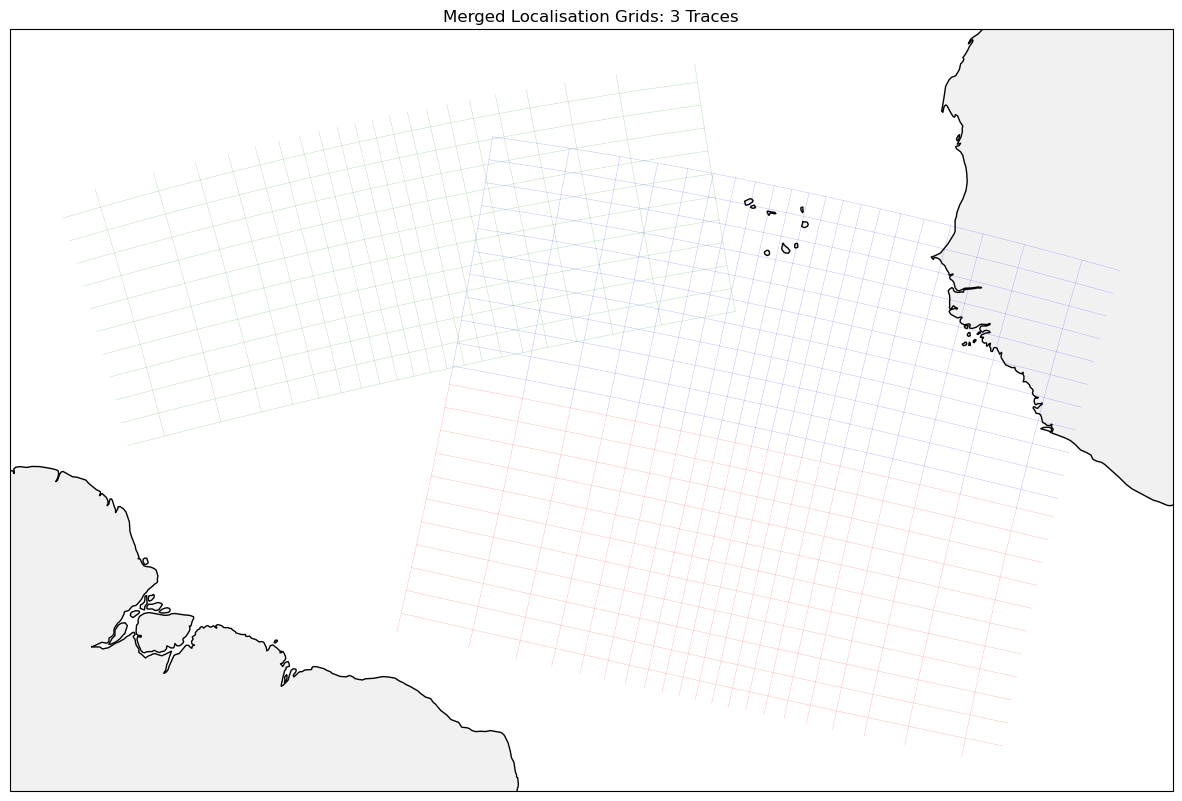

In [8]:
file_list = glob.glob('/home/qbialota/Téléchargements/test_fusion/*.nc')
plot_multiple_localisation_grid(file_list)

/tmp/ipykernel_60125/965571388.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(file_list)).colors  # Get a colormap with enough colors


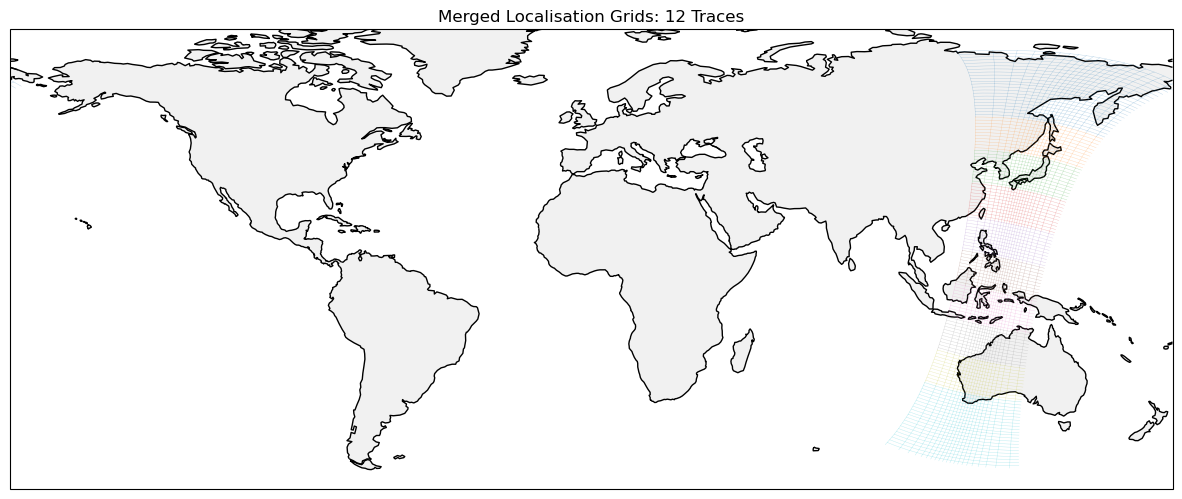

In [17]:
file_list = glob.glob('/home/qbialota/Téléchargements/trace_ghrsst/*.nc')
plot_multiple_localisation_grid(file_list)

In [4]:
from dask.distributed import Client, LocalCluster

# Set up a local cluster. This starts worker processes.
# You can customize n_workers, threads_per_worker, memory_limit, etc.
cluster = LocalCluster(n_workers=4, threads_per_worker=1, memory_limit='8GB')
client = Client(cluster)

# You can now open the dashboard link that appears to monitor progress
print(f"Dask Dashboard link: {client.dashboard_link}")

/home/qbialota/.conda/envs/cerbere-test-forge/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46103 instead
  warnings.warn(


Dask Dashboard link: http://127.0.0.1:46103/status


In [10]:
import numpy as np
import xarray as xr
from pyresample import geometry, kd_tree

def resample_trace(ds, target_area_def):
    """
    ds: The individual NetCDF xarray dataset
    target_area_def: The PyResample definition of the user's BBOX
    """
    # 1. Define the source geometry (The Curvilinear Grid)
    swath_def = geometry.SwathDefinition(lons=ds.lon, lats=ds.lat)

    # 2. Extract the data variable (e.g., 'surface_temp')
    data_array = ds.temperature.values

    # 3. Resample the data to the target grid
    # 'radius_of_influence' is the max distance (in meters) to look for a pixel
    resampled_data = kd_tree.resample_nearest(
        swath_def, data_array, target_area_def,
        radius_of_influence=5000, fill_value=np.nan
    )

    return resampled_data

In [11]:
# =============================================================================
# EXAMPLE 1: Concatenate tiles along track (preserves curvilinear grid)
# =============================================================================
import glob

file_list = sorted(glob.glob('/home/qbialota/Téléchargements/trace_ghrsst/*.nc'))
file_list = [file_list[0], file_list[1], file_list[2]]
print(f"Found {len(file_list)} files to merge")

# Simple concatenation - good for sequential swath segments
merged_concat = concatenate_tiles_along_track(
    file_list,
    output_path='/home/qbialota/Documents/cerbere-test/merged_concatenated.nc'
)
print(f"\nMerged dimensions: {dict(merged_concat.sizes)}")
print(f"Lat range: {merged_concat.lat.values.min():.2f} to {merged_concat.lat.values.max():.2f}")
merged_concat

Found 3 files to merge
Saved concatenated file to: /home/qbialota/Documents/cerbere-test/merged_concatenated.nc

Merged dimensions: {'time': 3, 'nj': 3240, 'ni': 2048}
Lat range: 37.14 to 74.25


<xarray.Dataset> Size: 1GB
Dimensions:                    (time: 3, nj: 3240, ni: 2048)
Coordinates:
  * time                       (time) datetime64[ns] 24B 2025-06-27T00:22:03 ...
    lat                        (nj, ni) float32 27MB 73.78 73.79 ... 37.15 37.14
    lon                        (nj, ni) float32 27MB 113.2 113.3 ... 151.7 151.8
Dimensions without coordinates: nj, ni
Data variables: (12/14)
    sea_surface_temperature    (time, nj, ni) float32 80MB -3.277e+04 ... -3....
    sst_dtime                  (time, nj, ni) timedelta64[ns] 159MB 00:00:00 ...
    sses_bias                  (time, nj, ni) float32 80MB -128.0 ... -128.0
    sses_standard_deviation    (time, nj, ni) float32 80MB -128.0 ... -128.0
    dt_analysis                (time, nj, ni) float32 80MB -128.0 ... -128.0
    wind_speed                 (time, nj, ni) float32 80MB -128.0 12.0 ... 10.0
    ...                         ...
    adi_dtime_from_sst         (time, nj, ni) float32 80MB -128.0 ... -128.0
    sources_of_adi             (time, nj, ni) float32 80MB -128.0 ... -128.0
    l2p_flags                  (time, nj, ni) float32 80MB 2.0 0.0 ... 0.0 0.0
    quality_level              (time, nj, ni) float32 80MB 0.0 1.0 ... 1.0 1.0
    satellite_zenith_angle     (time, nj, ni) float32 80MB 68.0 68.0 ... 68.0
    solar_zenith_angle         (time, nj, ni) float32 80MB -30.0 -30.0 ... -67.0
Attributes: (12/47)
    Conventions:                CF-1.4
    title:                      Sea Surface Temperature
    summary:                    The L2P product derived from METOP B AVHRR br...
    references:                 Low Earth Orbiter Sea Surface Temperature Pro...
    institution:                OSISAF
    history:                    METEO-FRANCE/CMS LEOSAFO processor
    ...                         ...
    project:                    Group for High Resolution Sea Surface Tempera...
    publisher_name:             The GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L2P
    cdm_data_type:              swath

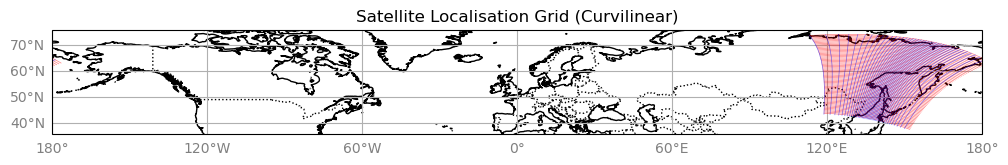

In [9]:
### Concatenated result
plot_localisation_grid("/home/qbialota/Documents/cerbere-test/merged_concatenated.nc")

In [4]:
from swath_merge import merge_tiles_to_regular_grid_OLD

# =============================================================================
# EXAMPLE 2: Merge tiles to a regular lat/lon grid (resampling)
# =============================================================================

file_list = sorted(glob.glob('/home/qbialota/Téléchargements/test_fusion/*.nc'))
# file_list = sorted(glob.glob('/home/qbialota/Téléchargements/trace_ghrsst/*.nc'))
# file_list = [file_list[2], file_list[3], file_list[4]]
print(f"Found {len(file_list)} files to merge")

# Resample to regular grid - good for overlapping tiles or uniform output
merged_regular = merge_tiles_to_regular_grid(
    file_list,
    output_path='/home/qbialota/Documents/cerbere-test/merged_regular_grid_gauss.nc',
    resolution=0.01,  # 0.01 degrees (~1km at equator)
    resample_method="gauss",
    sigma=5000,
    min_quality_level=2,
    variables=['sea_surface_temperature', 'wind_speed', 'quality_level']  # Subset of variables
)
print(f"\nMerged dimensions: {dict(merged_regular.sizes)}")
merged_regular

Found 3 files to merge
Processing: 20250627104603-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST_METOP_B-sstmgr_metop01_20250627_104603-v02.0-fv01.0.nc


/home/qbialota/.conda/envs/cerbere-test-forge/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 10000 m for some data points
  get_neighbour_info(source_geo_def,


Processing: 20250627104903-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST_METOP_B-sstmgr_metop01_20250627_104903-v02.0-fv01.0.nc


/home/qbialota/.conda/envs/cerbere-test-forge/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 10000 m for some data points
  get_neighbour_info(source_geo_def,


Processing: 20250627233403-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST_METOP_B-sstmgr_metop01_20250627_233403-v02.0-fv01.0.nc


/home/qbialota/.conda/envs/cerbere-test-forge/lib/python3.10/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 8 neighbours within 10000 m for some data points
  get_neighbour_info(source_geo_def,


Saved merged file to: /home/qbialota/Documents/cerbere-test/merged_regular_grid_gauss.nc

Merged dimensions: {'lat': 2928, 'lon': 4445}


<xarray.Dataset> Size: 208MB
Dimensions:                  (lat: 2928, lon: 4445)
Coordinates:
  * lat                      (lat) float64 23kB -6.452 -6.442 ... 22.81 22.82
  * lon                      (lon) float64 36kB -54.1 -54.09 ... -9.667 -9.657
Data variables:
    sea_surface_temperature  (lat, lon) float32 52MB nan nan nan ... nan nan nan
    wind_speed               (lat, lon) float32 52MB nan nan nan ... nan nan nan
    quality_level            (lat, lon) float32 52MB nan nan nan ... nan nan nan
    mosaic_quality_level     (lat, lon) float32 52MB nan nan nan ... nan nan nan
Attributes:
    title:              Merged satellite data (quality-aware regridding)
    source_files:       20250627104603-OSISAF-L2P_GHRSST-SSTsubskin-AVHRR_SST...
    resolution:         0.01 degrees
    resample_method:    gauss
    min_quality_level:  2

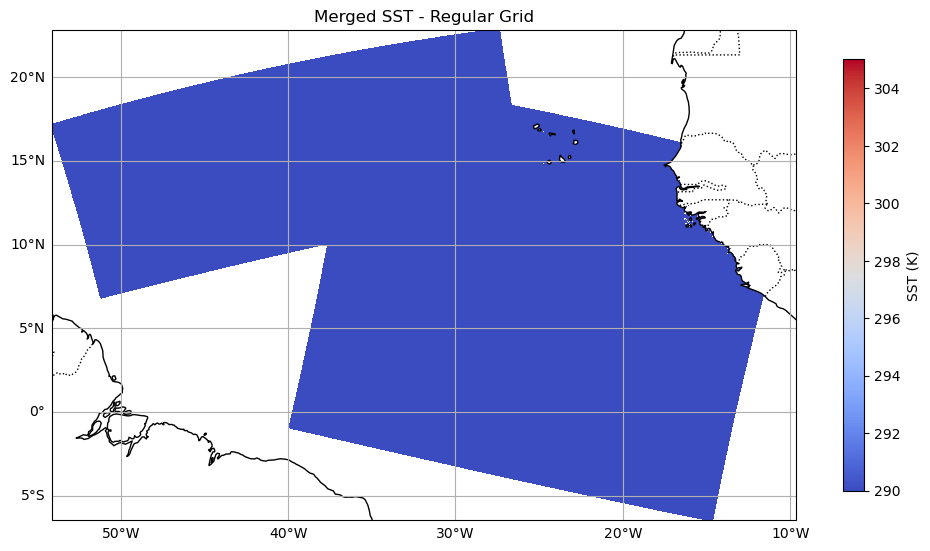

In [12]:
# =============================================================================
# VISUALIZE MERGED RESULT (regular grid)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot SST from merged regular grid
sst = merged_regular['sea_surface_temperature']
im = ax.pcolormesh(
    merged_regular.lon, merged_regular.lat, sst,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=290, vmax=305  # Adjust range as needed
)
plt.colorbar(im, ax=ax, label='SST (K)', shrink=0.7)

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Merged SST - Regular Grid")
plt.show()